<a href="https://colab.research.google.com/github/olhacherenkova/Python-projects/blob/main/Calculation_of_statistical_significance_for_A_B_test_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from statsmodels.stats.proportion import proportions_ztest

# Завантаження файлу з Google Drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Portfolio Project 2/

df = pd.read_csv("bq-results-20260122-092727-1769074368842.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Portfolio Project 2


,date,country,device,continent,channel,test,test_group,event_name,value
0,2020-11-06,Slovakia,mobile,Europe,Paid Search,2,2,session with orders,1
1,2020-11-06,Slovakia,mobile,Europe,Paid Search,1,2,session with orders,1
2,2020-12-09,El Salvador,mobile,Americas,Direct,4,2,session with orders,1
3,2020-12-09,El Salvador,mobile,Americas,Direct,3,2,session with orders,1
4,2020-12-21,Slovakia,mobile,Europe,Organic Search,4,2,session with orders,1


In [ ]:
# перевірка назв івентів
print(df["event_name"].unique())

['session with orders' 'new account' 'scroll' 'first_visit' 'page_view'
 'user_engagement' 'view_item' 'session_start' 'view_promotion'
 'select_promotion' 'view_search_results' 'add_shipping_info'
 'add_to_cart' 'begin_checkout' 'select_item' 'add_payment_info' 'click'
 'session' 'view_item_list']


In [ ]:
# Закріплюємо статично назви обраних метрик
metrics = ["add_payment_info", "add_shipping_info", "begin_checkout", "new account"]
denominator_value = "session"

In [ ]:
# Створуємо функцію для розрахунку необхідних метрик
def calculate_test_metrics(subset_A, subset_B, test, metrics, denominator_value, extra_params=None):
    """
    subset_A - дані для групи A
    subset_B - дані для групи B
    test - номер тесту
    metrics - список метрик для аналізу
    denominator_value - назва події-знаменника
    extra_params - додаткові параметри для результату (наприклад, device)
    """
    # Створюємо список для збереження майбутніх результатів
    rows = []
    # Цикл для перебору усіх метрик
    for metric in metrics:
        # Для групи А:
        numerator_A = subset_A[subset_A["event_name"] == metric]["value"].sum()
        denominator_A = subset_A[subset_A["event_name"] == denominator_value]["value"].sum()

        # Для групи В:
        numerator_B = subset_B[subset_B["event_name"] == metric]["value"].sum()
        denominator_B = subset_B[subset_B["event_name"] == denominator_value]["value"].sum()

       # Розрахунок конверсійних мерик
        conversion_rate_A = numerator_A / denominator_A
        conversion_rate_B = numerator_B / denominator_B

        # Розрахунок зміни метрики
        metric_change = (conversion_rate_B / conversion_rate_A - 1) * 100

        # Розрахунок z-stat та p_value
        count = np.array([numerator_B, numerator_A])
        nobs = np.array([denominator_B, denominator_A])
        stat, pval = proportions_ztest(count, nobs)

        # Визначення статистичної значущості
        significance = pval < 0.05

        # Створюємо словник з усіма необхідними метриками
        result = {
            "test_number": test,
            "metric": metric + "/" + denominator_value,
            "numerator_ev": metric,
            "denominator_ev": denominator_value,
            "numerator_group_B": numerator_B,
            "denominator_group_B": denominator_B,
            "conversion_rate_group_B": conversion_rate_B,
            "numerator_group_A": numerator_A,
            "denominator_group_A": denominator_A,
            "conversion_rate_group_A": conversion_rate_A,
            "metric_change": metric_change,
            "z-stat": stat,
            "p_value": pval,
            "significance": significance
        }

        # Додаємо extra_params, якщо вони є
        if extra_params:
            result.update(extra_params)
        rows.append(result)

    return rows

In [ ]:
# Цикл для кожного тесту
result_data = []
for test in df["test"].unique():
    # Відфільтровуємо значення для кожного тесту
    subset_test = df[df["test"] == test]
    # Створюємо два датафрейми для двох груп тестування А і В
    subset_group_A = subset_test[subset_test["test_group"] == 1]
    subset_group_B = subset_test[subset_test["test_group"] == 2]

    # Викликаємо функцію та додаємо результати
    test_results = calculate_test_metrics(subset_group_A, subset_group_B, test, metrics, denominator_value)
    result_data.extend(test_results)

# Перетворюємо у датафрейм
df_summary = pd.DataFrame(result_data)
print(df_summary)

    test_number                     metric       numerator_ev denominator_ev  \
0             2   add_payment_info/session   add_payment_info        session   
1             2  add_shipping_info/session  add_shipping_info        session   
2             2     begin_checkout/session     begin_checkout        session   
3             2        new account/session        new account        session   
4             1   add_payment_info/session   add_payment_info        session   
5             1  add_shipping_info/session  add_shipping_info        session   
6             1     begin_checkout/session     begin_checkout        session   
7             1        new account/session        new account        session   
8             4   add_payment_info/session   add_payment_info        session   
9             4  add_shipping_info/session  add_shipping_info        session   
10            4     begin_checkout/session     begin_checkout        session   
11            4        new account/sessi

In [ ]:
# Зберігаємо датафрейм
df_summary.to_csv("portfolio_project_2.csv", index=False)

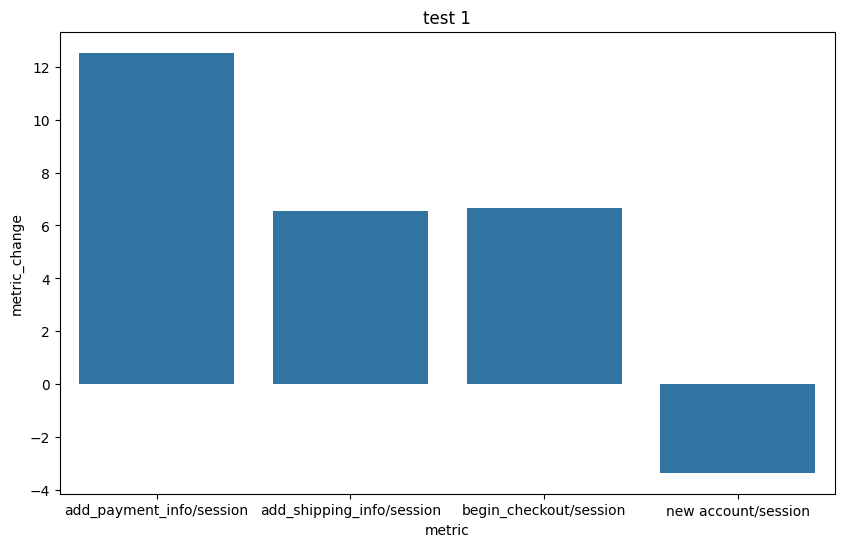

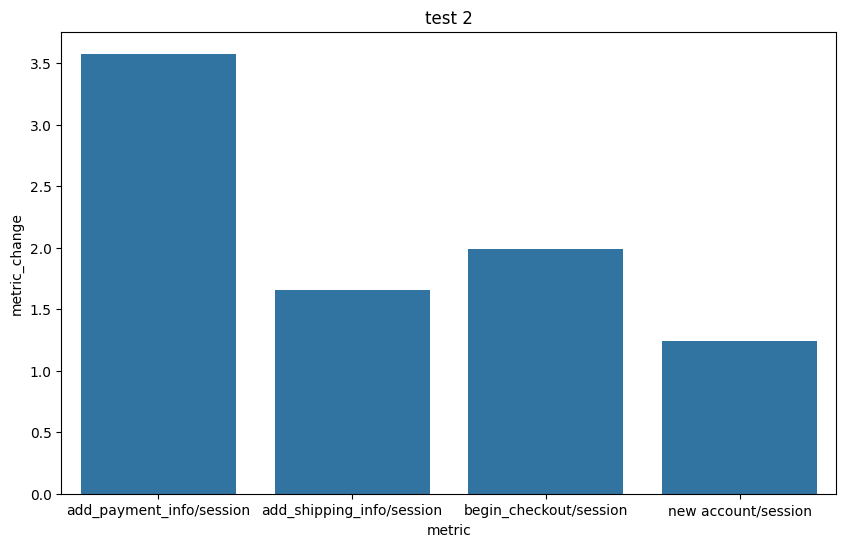

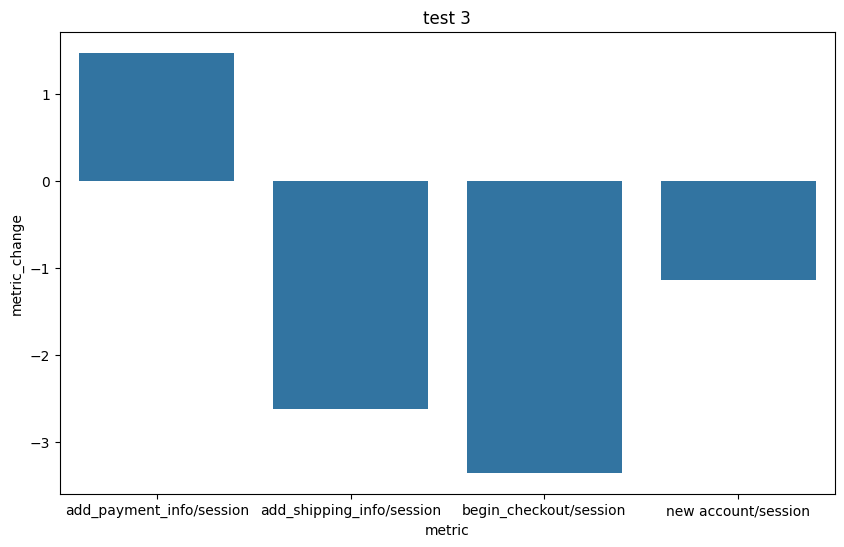

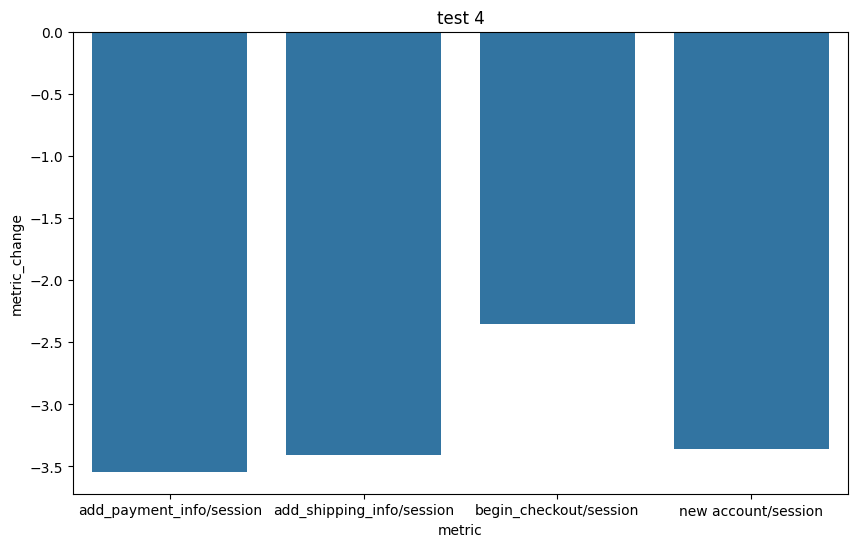

In [ ]:
plt.figure(figsize=(10, 6))
test_1= df_summary[(df_summary["test_number"]==1)]
sns.barplot(data =test_1, x='metric', y='metric_change')
plt.title("test 1")
plt.show()
test_2= df_summary[(df_summary['test_number']==2)]
plt.figure(figsize=(10, 6))
sns.barplot(data =test_2, x='metric', y='metric_change')
plt.title("test 2")
plt.show()
test_3= df_summary[(df_summary['test_number']==3)]
plt.figure(figsize=(10, 6))
sns.barplot(data =test_3, x='metric', y='metric_change')
plt.title("test 3")
plt.show()
test_4= df_summary[(df_summary['test_number']==4)]
plt.figure(figsize=(10, 6))
sns.barplot(data =test_4, x='metric', y='metric_change')
plt.title("test 4")
plt.show()

Висновок по тоталу. По тесту 1 статистично значущимим є зміни у метриках add_payment_info/session, add_shipping_info/session, begin_checkout/session - усі метрики зросли - можна впроваджувати зміни, що тестувалися.
 По тесту 2 усі зміни в метриках є не статистично значущими - залишаємо все без змін.
 По тесту 3- є падіння метрики begin_checkout/session і воно статистично значуще, всі інші метрики змінились статистично не значуще - зміни не впроваджуємо.
 По тесту 4 - зміни в метриках begin_checkout/session,new account/session є статистично значущими, але метрики знизились - тому ніяких змін не застосовуємо.

In [ ]:
# Цикл для кожного пристрою
result_data_device = []
for device in df['device'].unique():
  subset_device = df[df['device'] == device]
  # Цикл для кожного тесту
  for test in df['test'].unique():
    # Відфільтровуємо значення для кожного тесту
    subset_test_device = subset_device[subset_device['test'] == test]
    # Створюємо два датафрейми для двох груп тестування А і В
    subset_group_A = subset_test_device[subset_test_device['test_group'] == 1]
    subset_group_B = subset_test_device[subset_test_device['test_group'] == 2]

    # Викликаємо функцію та додаємо результати
    test_results_device = calculate_test_metrics(subset_group_A, subset_group_B, test, metrics, denominator_value, extra_params={'device': device})
    result_data_device.extend(test_results_device)

# Перетворюємо у датафрейм
df_summary_device = pd.DataFrame(result_data_device)
print(df_summary_device)

    test_number                     metric       numerator_ev denominator_ev  \
0             2   add_payment_info/session   add_payment_info        session   
1             2  add_shipping_info/session  add_shipping_info        session   
2             2     begin_checkout/session     begin_checkout        session   
3             2        new account/session        new account        session   
4             1   add_payment_info/session   add_payment_info        session   
5             1  add_shipping_info/session  add_shipping_info        session   
6             1     begin_checkout/session     begin_checkout        session   
7             1        new account/session        new account        session   
8             4   add_payment_info/session   add_payment_info        session   
9             4  add_shipping_info/session  add_shipping_info        session   
10            4     begin_checkout/session     begin_checkout        session   
11            4        new account/sessi

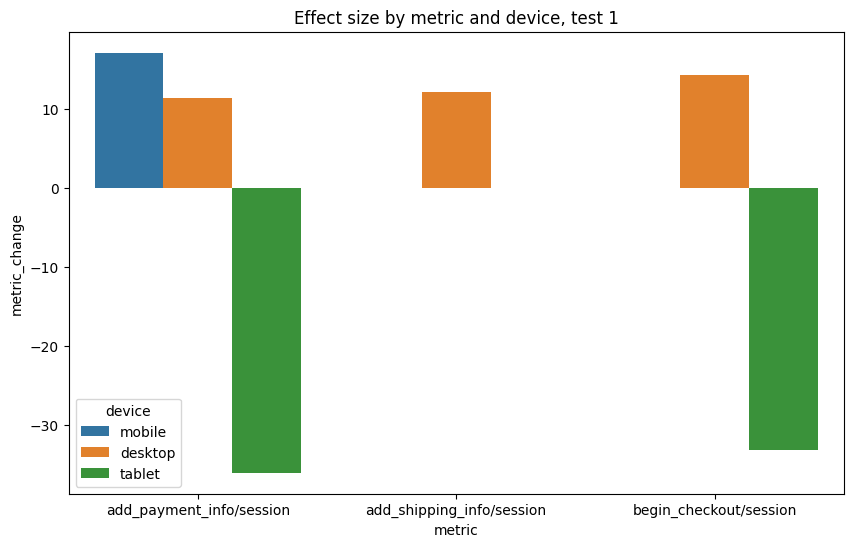

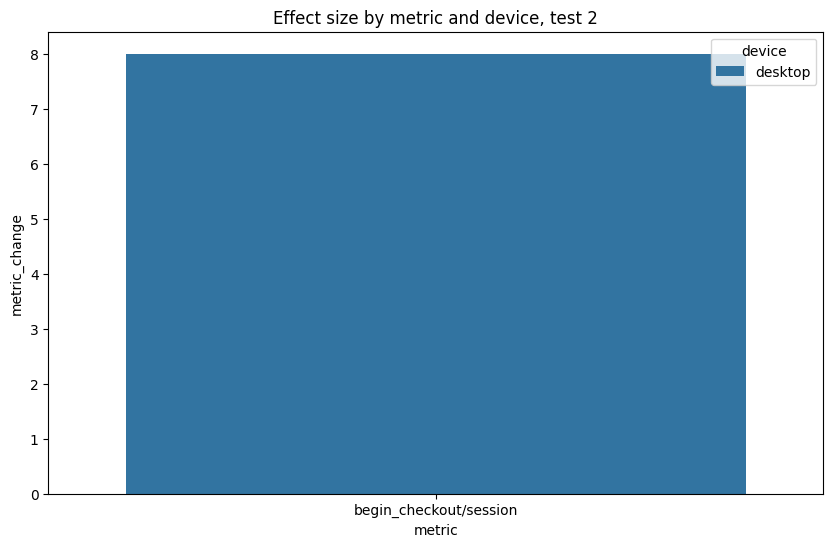

<Figure size 1000x600 with 0 Axes>

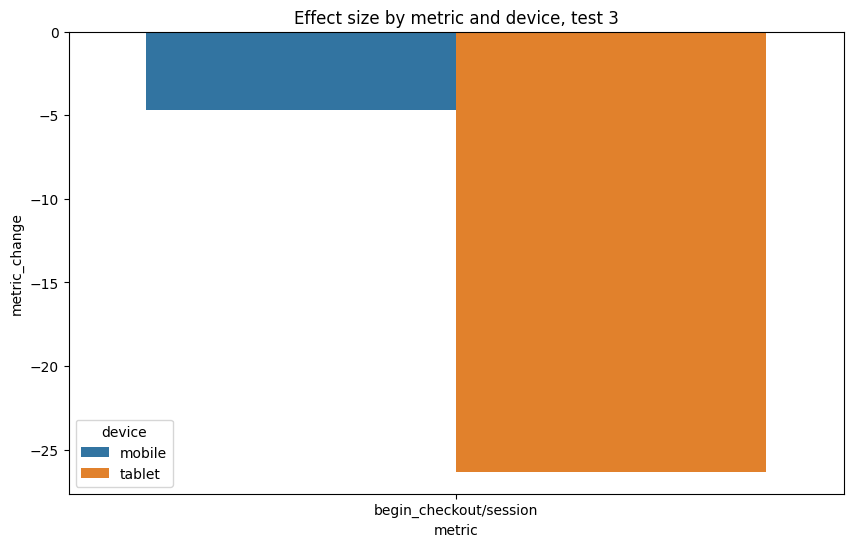

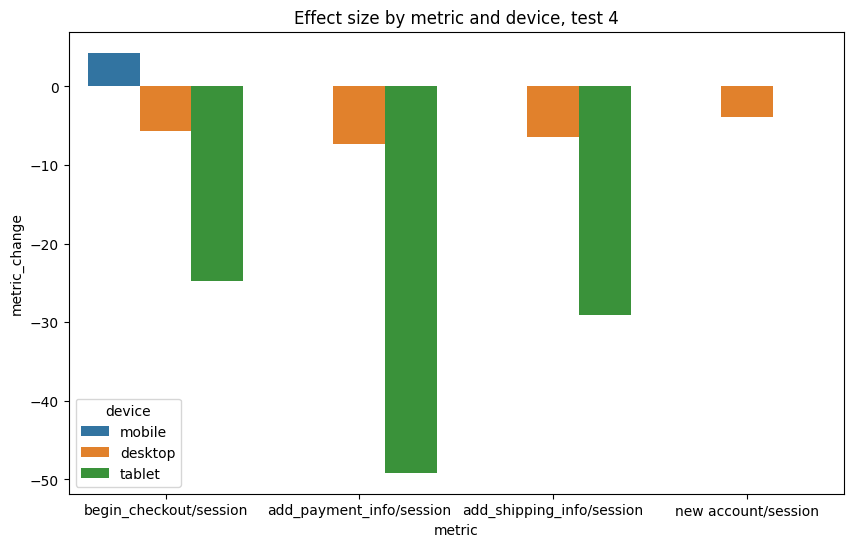

In [ ]:
test1_device = df_summary_device[(df_summary_device['significance']==True) & (df_summary_device['test_number']==1)]
plt.figure(figsize=(10, 6))
sns.barplot(data =test1_device, x='metric', y='metric_change', hue='device')
plt.title("Effect size by metric and device, test 1")
plt.show()
test2_device = df_summary_device[(df_summary_device['significance']==True) & (df_summary_device['test_number']==2)]
plt.figure(figsize=(10, 6))
sns.barplot(data=test2_device, x='metric', y='metric_change', hue='device')
plt.title("Effect size by metric and device, test 2")
plt.show()
test3_device = df_summary_device[(df_summary_device['significance']==True) & (df_summary_device['test_number']==3)]
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
sns.barplot(data =test3_device, x='metric', y='metric_change', hue='device')
plt.title("Effect size by metric and device, test 3")
plt.show()
test4_device = df_summary_device[(df_summary_device['significance']==True) & (df_summary_device['test_number']==4)]
plt.figure(figsize=(10, 6))
sns.barplot(data =test4_device, x="metric", y="metric_change", hue="device")
plt.title("Effect size by metric and device, test 4")
plt.show()


Висновок у розрірізі девайсів.
По мобільним пристороям є статистично значуще зростання метрики add_payment_info/session по 1 тесту та begin_checkout/session у 4 тесті.
Зміни по 1 тесту ми застосовуємо в тоталі,а по 4 тесту по метриці begin_checkout/session можна застосувати лише до мобільних пристроїв.
По дестопним присторям - add_payment_info/session, add_shipping_info/session,begin_checkout/session у 1 тесті статистично значуще зростають і в тоталі, а ось метрика begin_checkout/session у тесті 2 статистично зроста  - можна застосувати зміни у цьому сегменті.  
По 1 тесту по планшетам  з загального результату слід виключити зміни по метрикам add_payment_info/session та begin_checkout/session  - ці метрики впали статистично значуще і варто дослідити сегмент планшетів окремо.

# [Аналітичний дашборд у Tableau Public](https://public.tableau.com/views/ABTest_17690801561330/ABTest?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

##[Файл csv з результатами розрахунків першого етапу завдання](https://drive.google.com/file/d/13HzFEtPme3F5q8GXu5q9wVb1sN0vtLpl/view?usp=sharing)